In [1]:
import torchmetrics.segmentation
from torch.xpu import device

from DatasetLoading import RepairDatasetLoader
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import lightning as L
import torch
from lightning.pytorch.loggers import WandbLogger
import os

import math
import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from GridReconstruction import GridReconstructionNetwork
from GridReconstruction import GridReconstruction
from NerfRepresentationUtils import plot_colored_voxels
from NerfRepresentationUtils import plot_opacity_tensor
import torch.nn.functional as F

torch.set_float32_matmul_precision('medium')

from tqdm import tqdm

from torchvision.utils import save_image

from InterpolatableGridReconstruction import RayManager

from copy import copy

In [2]:
dataset_loader = RepairDatasetLoader(batch_size=1, dataset_type="InterpolatableGridDataset",
                                         representation_folder_name="interpolatableGrids", num_workers=2)

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [4]:
ray_manager = RayManager(device=torch.device("cpu"))

In [5]:
test_dataloader = dataset_loader.test_dataloader()

In [6]:
grid, opacity_multiplier, blank_edge_rays_o, blank_edge_rays_d, rgb_rays_o, rgb_rays_d, rgb_rays_c = next(iter(test_dataloader))
xyz_sampled, z_vals, ray_valid = ray_manager.sample_ray(blank_edge_rays_o, blank_edge_rays_d)
density_grid = grid[:, :96]
colour_grid = grid[:, 96:]

In [7]:
grid.shape

torch.Size([1, 384, 96, 96, 96])

In [8]:
colour_grid.shape

torch.Size([1, 288, 96, 96, 96])

In [9]:
xyz_sampled.shape

torch.Size([1, 50000, 330, 3])

In [10]:
ray_valid.shape

torch.Size([1, 50000, 330])

In [11]:
density_grid.shape

torch.Size([1, 96, 96, 96, 96])

In [12]:
weight = ray_manager.get_opacity_weight(xyz_sampled, density_grid, ray_valid, z_vals)

In [13]:
weight.shape

torch.Size([1, 50000, 330])

In [14]:
rgbs = ray_manager.get_colour(xyz_sampled, colour_grid, weight, False)

In [16]:
rgbs.shape

torch.Size([1, 50000, 3])

In [47]:

def show_tensor_image(image, title=None, figsize=(10, 10), normalize=False):
    """
    Display a PyTorch image tensor using matplotlib.

    Args:
        image (torch.Tensor): Image tensor of shape (C, H, W), (H, W), or (1, H, W).
        title (str, optional): Title for the plot.
        figsize (tuple): Figure size.
        normalize (bool): If True, assumes values are in [-1, 1] and rescales to [0, 1].
    """
    if not isinstance(image, torch.Tensor):
        raise TypeError("Input must be a torch.Tensor")

    # Move to CPU, detach from computation graph
    image = image.detach().cpu()

    # Rescale if normalized to [-1, 1]
    if normalize:
        image = (image + 1) / 2

    # Clamp values to valid range
    image = image.clamp(0, 1)

    # Handle different tensor shapes
    if image.ndim == 3:
        # (C, H, W) -> (H, W, C)
        image = image.permute(1, 2, 0)

        # If grayscale with one channel, remove the channel dimension
        if image.shape[2] == 1:
            image = image.squeeze(2)
            cmap = "gray"
        else:
            cmap = None

    elif image.ndim == 2:
        cmap = "gray"

    else:
        raise ValueError(f"Unsupported image shape: {image.shape}")

    plt.figure(figsize=figsize)
    plt.imshow(image, cmap=cmap)
    plt.axis("off")


    if title:
        plt.title(title)

    plt.show()



def visualise_sample_pose(pose, density_grid, colour_grid, save_name = None, chunk=50000):
    sample_pose = np.load(f"SamplePoses/{pose}.npz")
    pose_rays_o = torch.tensor(sample_pose["rays_o"])
    pose_rays_d = torch.tensor(sample_pose["rays_d"])

    all_rgbs = []
    N_rays_all = pose_rays_o.shape[0]
    for chunk_idx in tqdm(range(N_rays_all // chunk + int(N_rays_all % chunk > 0))):
        rays_o = pose_rays_o[chunk_idx * chunk:(chunk_idx + 1) * chunk].to(device)
        rays_d = pose_rays_d[chunk_idx * chunk:(chunk_idx + 1) * chunk].to(device)

        xyz_sampled, z_vals, ray_valid = sample_ray(rays_o, rays_d, device=device)
        weight = get_opacity_weight(xyz_sampled, density_grid, ray_valid, z_vals)
        rgbs = get_colour(xyz_sampled, colour_grid, weight, True)
        all_rgbs.append(rgbs.cpu())
    all_rgbs = torch.cat(all_rgbs)

    all_rgbs = all_rgbs.view(1080, 1920, 3).permute(2, 0, 1)

    show_tensor_image(all_rgbs)

    if save_name is not None:
        save_image(all_rgbs, save_name)




In [32]:
test_dataloader.dataset.piece_names[0]

'RPf_00204.npz'

100%|██████████| 42/42 [00:01<00:00, 33.00it/s]


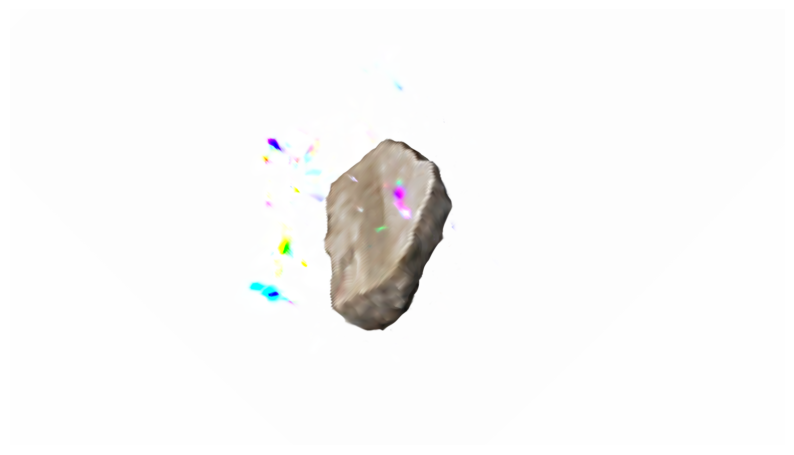

In [53]:
visualise_sample_pose("SamplePose5", density_grid.to(device), colour_grid.to(device), save_name = "testPose5Output.png")

RuntimeError: [enforce fail at alloc_cpu.cpp:127] err == 0. DefaultCPUAllocator: can't allocate memory: you tried to allocate 167981643648 bytes. Error code 12 (Cannot allocate memory)

torch.Size([50000, 3])

In [79]:
device

device(type='cuda', index=0)

In [16]:
rgb.shape

torch.Size([2073600, 3])

In [ ]:
rgb = torch.zeros((*xyz_sampled.shape[:2], 3), device=xyz_sampled.device)

if ray_valid.any():
    xyz_sampled = self.normalize_coord(xyz_sampled)
    sigma_feature = self.compute_densityfeature(xyz_sampled[ray_valid])

    validsigma = self.feature2density(sigma_feature)
    sigma[ray_valid] = validsigma


alpha, weight, bg_weight = raw2alpha(sigma, dists * self.distance_scale)

app_mask = weight > self.rayMarch_weight_thres

if app_mask.any():
    app_features = self.compute_appfeature(xyz_sampled[app_mask])
    valid_rgbs = self.renderModule(xyz_sampled[app_mask], viewdirs[app_mask], app_features)
    rgb[app_mask] = valid_rgbs

acc_map = torch.sum(weight, -1)
rgb_map = torch.sum(weight[..., None] * rgb, -2)

if white_bg or (is_train and torch.rand((1,))<0.5):
    rgb_map = rgb_map + (1. - acc_map[..., None])


rgb_map = rgb_map.clamp(0,1)

In [24]:
torch.load("tensorf_RPf_00017_CP_96_20000_NoBasisMat.th", weights_only=False).keys()

dict_keys(['kwargs', 'state_dict', 'alphaMask.shape', 'alphaMask.mask', 'alphaMask.aabb'])

In [30]:
torch.load("tensorf_RPf_00017_CP_96_20000_NoBasisMat.th", weights_only=False)["kwargs"]["aabb"]

tensor([[-1.7541, -1.7541, -1.7541],
        [ 1.7541,  1.7541,  1.7541]], device='cuda:0')

In [ ]:
 'rayMarch_weight_thres': 0.0001,
 'fea2denseAct': 'softplus',
 'near_far': [0.01, 6.0],
 'step_ratio': 0.5,
 'shadingMode': 'NoBasisMat',
 'pos_pe': 6,
 'view_pe': 2,
 'fea_pe': 2,
 'featureC': 128}

In [34]:
torch.load("tensorf_RPf_00059_CP_96_20000_NoBasisMat.th", weights_only=False)["kwargs"]


{'aabb': tensor([[-1.7541, -1.7541, -1.7541],
         [ 1.7541,  1.7541,  1.7541]], device='cuda:0'),
 'gridSize': [96, 96, 96],
 'density_n_comp': [96],
 'appearance_n_comp': [288],
 'app_dim': 27,
 'density_shift': -10,
 'alphaMask_thres': 0.0001,
 'distance_scale': 25,
 'rayMarch_weight_thres': 0.0001,
 'fea2denseAct': 'softplus',
 'near_far': [0.01, 6.0],
 'step_ratio': 0.5,
 'shadingMode': 'NoBasisMat',
 'pos_pe': 6,
 'view_pe': 2,
 'fea_pe': 2,
 'featureC': 128}

In [4]:
lightning_model = GridReconstruction.load_from_checkpoint("WO+Dice+Mask_scale_3.ckpt")
model = lightning_model.model
model.eval()
model.to(device)

/home/enego/Documents/masters/RayRepresentationTesting/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/migration/utils.py:56: The loaded checkpoint was produced with Lightning v2.6.1, which is newer than your current Lightning version: v2.6.0
/home/enego/Documents/masters/RayRepresentationTesting/.venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: DiceScore metric currently defaults to `average=micro`, but will change to`average=macro` in the v1.9 release. If you've explicitly set this parameter, you can ignore this warning.
  warnings.warn(*args, **kwargs)


GridReconstructionNetwork(
  (first_encoder): Sequential(
    (0): Conv3d(32, 192, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (1): BatchNorm3d(192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv3d(192, 192, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (4): BatchNorm3d(192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv3d(192, 384, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (8): BatchNorm3d(384, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Conv3d(384, 384, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (12): BatchNorm3d(384, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU()
   

In [5]:
lightning_model.model.first_encoder

Sequential(
  (0): Conv3d(32, 192, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
  (1): BatchNorm3d(192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Conv3d(192, 192, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
  (4): BatchNorm3d(192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): ReLU()
  (6): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (7): Conv3d(192, 384, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
  (8): BatchNorm3d(384, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (9): ReLU()
  (10): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (11): Conv3d(384, 384, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
  (12): BatchNorm3d(384, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (13): ReLU()
  (14): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=F

In [6]:
test_dataset = dataset_loader.test_dataloader().dataset

In [7]:
"RPf_00347.npz" in test_dataset.piece_names

True

In [8]:
test_dataset.piece_names.index("RPf_00347.npz")

154

In [9]:
representation, idx_tensors, colour_tensor, directions = test_dataset.get_testing_items(154)

In [10]:
representation_opacity = representation.unsqueeze(0)[:, -1:]

In [11]:
representation_opacity.shape

torch.Size([1, 1, 96, 96, 96])

In [12]:
torch.sum(representation_opacity, dim=[2, 3, 4])

tensor([[4431.7119]])

In [13]:
test_dataset.piece_names[2]

'RPf_00206.npz'

In [14]:
representation.shape

torch.Size([32, 96, 96, 96])

/home/enego/Documents/masters/RayRepresentationTesting/NerfRepresentationUtils.py:112: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


(<Figure size 800x800 with 1 Axes>,
 <Axes3D: xlabel='x', ylabel='y', zlabel='z'>)

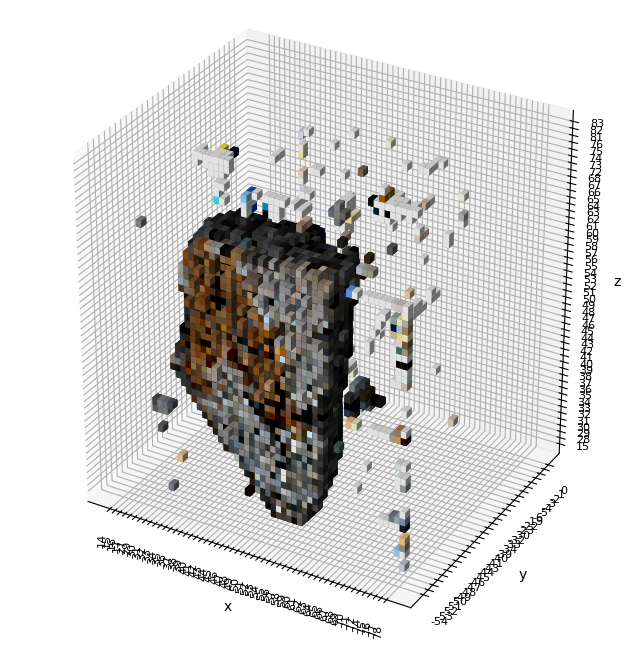

In [15]:
plot_colored_voxels(idx_tensors, colour_tensor)

In [16]:
with torch.no_grad():
    reconstructed_grid = model(representation.unsqueeze(0).to(device)).squeeze(0).cpu()

In [17]:
weights = reconstructed_grid[-1]

In [18]:
weights.shape

torch.Size([96, 96, 96])

In [19]:
r_idx_tensors = torch.where(weights > 0.3)

In [20]:
r_idx_tensors[0].shape[0]

5476

In [21]:
random_directions = F.normalize(torch.randn((r_idx_tensors[0].shape[0], 3)), p=2, dim=1)
latent = reconstructed_grid[:-1, r_idx_tensors[0], r_idx_tensors[1], r_idx_tensors[2]].T
r_colours = test_dataset.latent2representation.get_colour_from_latent(latent, random_directions).detach()


In [22]:
random_directions2 = F.normalize(torch.randn((idx_tensors[0].shape[0], 3)), p=2, dim=1)
latent2 = representation[:-1, idx_tensors[0], idx_tensors[1], idx_tensors[2]].T
r_colours2 = test_dataset.latent2representation.get_colour_from_latent(latent2, random_directions2).detach()


In [23]:
r_colours

tensor([[0.0883, 0.0142, 0.2639],
        [0.0956, 0.0445, 0.2662],
        [0.0584, 0.0318, 0.2325],
        ...,
        [0.3672, 0.3370, 0.3781],
        [0.3896, 0.3315, 0.3884],
        [0.3344, 0.2531, 0.3507]])

In [24]:
r_idx_tensors

(tensor([33, 33, 33,  ..., 63, 63, 63]),
 tensor([48, 48, 48,  ..., 51, 51, 51]),
 tensor([45, 46, 47,  ..., 63, 64, 65]))

/home/enego/Documents/masters/RayRepresentationTesting/NerfRepresentationUtils.py:112: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


(<Figure size 800x800 with 1 Axes>,
 <Axes3D: xlabel='x', ylabel='y', zlabel='z'>)

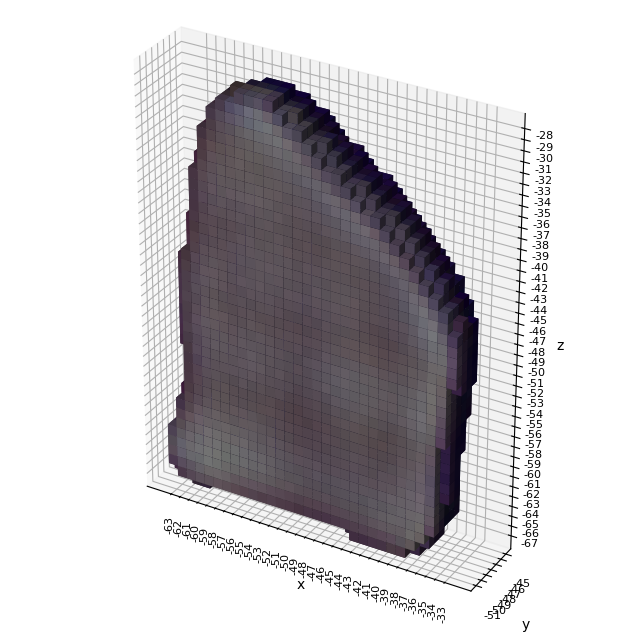

In [26]:
plot_colored_voxels(r_idx_tensors, r_colours, axis_flips=(-1, -1, -1))

/home/enego/Documents/masters/RayRepresentationTesting/NerfRepresentationUtils.py:112: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


(<Figure size 800x800 with 1 Axes>,
 <Axes3D: xlabel='x', ylabel='y', zlabel='z'>)

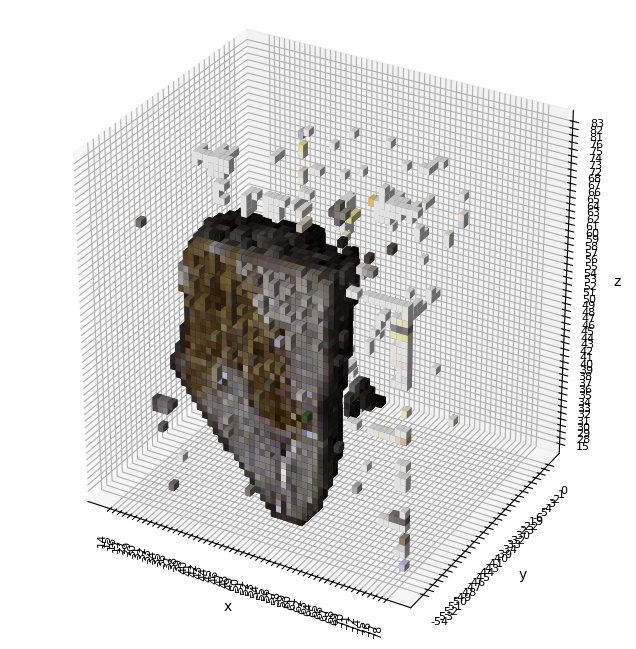

In [55]:
lot_colored_voxels(idx_tensors, r_colours2)


54


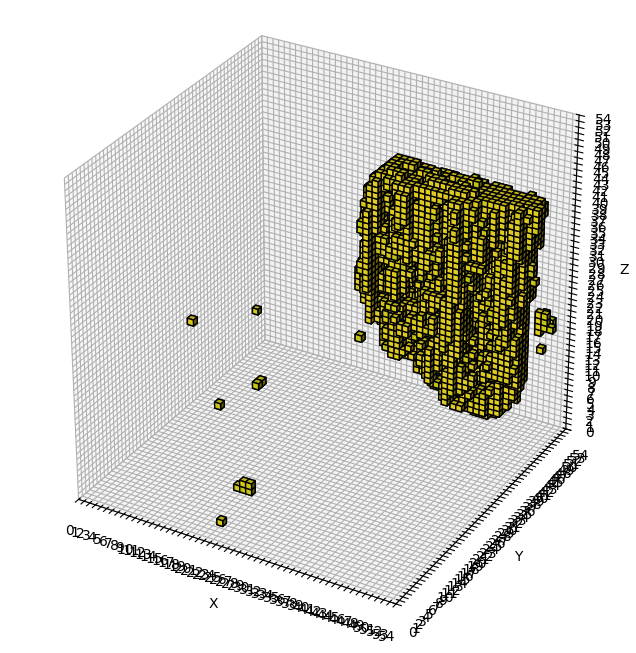

(<Figure size 800x800 with 1 Axes>,
 <Axes3D: xlabel='X', ylabel='Y', zlabel='Z'>,
 (slice(13, 67, None), slice(0, 54, None), slice(27, 81, None)))

In [18]:
plot_opacity_tensor(representation[-1], threshold=0.95)

69


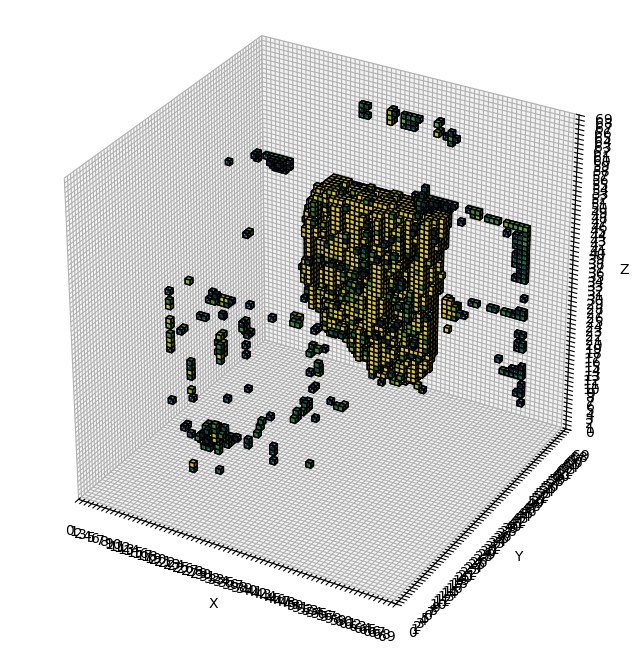

(<Figure size 800x800 with 1 Axes>,
 <Axes3D: xlabel='X', ylabel='Y', zlabel='Z'>,
 (slice(12, 81, None), slice(0, 69, None), slice(15, 84, None)))

In [19]:
plot_opacity_tensor(representation[-1], threshold=0.3)

40


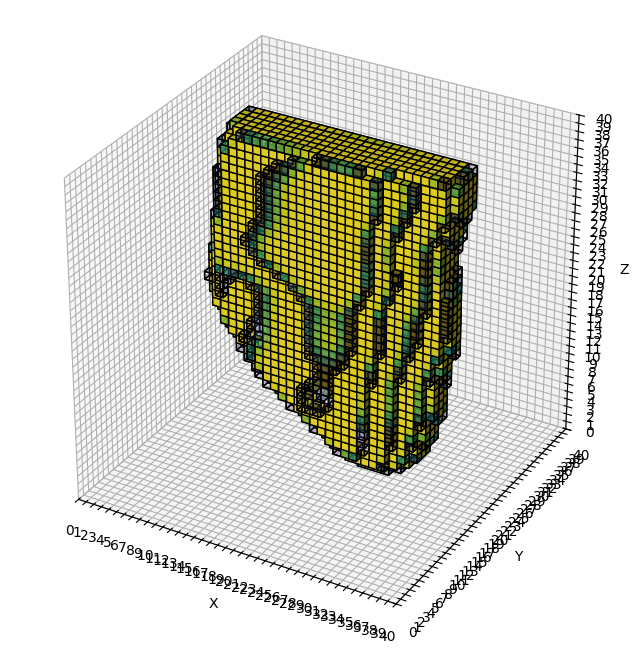

(<Figure size 800x800 with 1 Axes>,
 <Axes3D: xlabel='X', ylabel='Y', zlabel='Z'>,
 (slice(28, 68, None), slice(28, 68, None), slice(27, 67, None)))

In [57]:
plot_opacity_tensor(reconstructed_grid[-1], threshold=0.05)


In [21]:
import itertools

In [98]:
axis_swaps = list(itertools.permutations([0, 1, 2]))
axis_flips = [(1, 1, 1)] + list(set(itertools.permutations([1, 1, -1])))
pairs = [list(p) for p in itertools.product(range(len(axis_swaps)), range(len(axis_flips)))]
rotations = [(axis_swaps[a], axis_flips[b]) for a, b in pairs]

In [100]:
axis_swaps

[(0, 1, 2), (0, 2, 1), (1, 0, 2), (1, 2, 0), (2, 0, 1), (2, 1, 0)]

In [99]:
axis_flips

[(1, 1, 1), (1, 1, -1), (1, -1, 1), (-1, 1, 1)]

In [92]:
rotations

[(array([0, 1, 2]), array([1, 1, 1])),
 (array([0, 1, 2]), array([ 1,  1, -1])),
 (array([0, 1, 2]), array([ 1, -1,  1])),
 (array([0, 1, 2]), array([-1,  1,  1])),
 (array([0, 2, 1]), array([1, 1, 1])),
 (array([0, 2, 1]), array([ 1,  1, -1])),
 (array([0, 2, 1]), array([ 1, -1,  1])),
 (array([0, 2, 1]), array([-1,  1,  1])),
 (array([1, 0, 2]), array([1, 1, 1])),
 (array([1, 0, 2]), array([ 1,  1, -1])),
 (array([1, 0, 2]), array([ 1, -1,  1])),
 (array([1, 0, 2]), array([-1,  1,  1])),
 (array([1, 2, 0]), array([1, 1, 1])),
 (array([1, 2, 0]), array([ 1,  1, -1])),
 (array([1, 2, 0]), array([ 1, -1,  1])),
 (array([1, 2, 0]), array([-1,  1,  1])),
 (array([2, 0, 1]), array([1, 1, 1])),
 (array([2, 0, 1]), array([ 1,  1, -1])),
 (array([2, 0, 1]), array([ 1, -1,  1])),
 (array([2, 0, 1]), array([-1,  1,  1])),
 (array([2, 1, 0]), array([1, 1, 1])),
 (array([2, 1, 0]), array([ 1,  1, -1])),
 (array([2, 1, 0]), array([ 1, -1,  1])),
 (array([2, 1, 0]), array([-1,  1,  1]))]

In [93]:
len(rotations)

24

In [95]:
sum((1, -1 ,-1))

-1

In [96]:
def get_rotation_a_to_b(a, b):
    axis_swap_a = a[0]
    axis_swap_b = b[0]
    axis_flip_a = a[1]
    axis_flip_b = b[1]

    axis_swap = np.arange(3)[np.argsort(axis_swap_a)][axis_swap_b]
    axis_flip = axis_flip_a * axis_flip_b
    if np.sum(axis_flip) < -1:
        axis_flip = axis_flip * -1

    return axis_swap, axis_flip

In [97]:
test_a = rotations[7]
test_b = rotations[15]
a_to_b = get_rotation_a_to_b(test_a, test_b)
print(test_b)
print(test_a[0][a_to_b[0]])
print(test_a[1] * a_to_b[1])
a_to_b

(array([1, 2, 0]), array([-1,  1,  1]))
[1 2 0]
[-1  1  1]


(array([2, 1, 0]), array([1, 1, 1]))

In [120]:
def get_normal_category(rotations):
    swaps, flips = zip(*rotations)
    category = torch.zeros(len(rotations), 6)
    swaps = torch.tensor(swaps)

    y_flips = [flip[1] for flip in flips]
    for i, x in enumerate(y_flips):
        if x == 1:
            category[i, :3] = (swaps[i] == 1).float()
        else:
            category[i, -3:] = (swaps[i] == 1).float()

    return category

In [121]:
rotations

[((0, 1, 2), (1, 1, 1)),
 ((0, 1, 2), (1, 1, -1)),
 ((0, 1, 2), (1, -1, 1)),
 ((0, 1, 2), (-1, 1, 1)),
 ((0, 2, 1), (1, 1, 1)),
 ((0, 2, 1), (1, 1, -1)),
 ((0, 2, 1), (1, -1, 1)),
 ((0, 2, 1), (-1, 1, 1)),
 ((1, 0, 2), (1, 1, 1)),
 ((1, 0, 2), (1, 1, -1)),
 ((1, 0, 2), (1, -1, 1)),
 ((1, 0, 2), (-1, 1, 1)),
 ((1, 2, 0), (1, 1, 1)),
 ((1, 2, 0), (1, 1, -1)),
 ((1, 2, 0), (1, -1, 1)),
 ((1, 2, 0), (-1, 1, 1)),
 ((2, 0, 1), (1, 1, 1)),
 ((2, 0, 1), (1, 1, -1)),
 ((2, 0, 1), (1, -1, 1)),
 ((2, 0, 1), (-1, 1, 1)),
 ((2, 1, 0), (1, 1, 1)),
 ((2, 1, 0), (1, 1, -1)),
 ((2, 1, 0), (1, -1, 1)),
 ((2, 1, 0), (-1, 1, 1))]

In [122]:
get_normal_category(rotations)

tensor([[0., 1., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0.],
        [0., 1., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1.],
        [0., 0., 1., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0.],
        [1., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0.],
        [1., 0., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1.],
        [0., 0., 1., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0.],
        [0., 1., 0., 0., 0., 0.]])

In [7]:
with torch.no_grad():
    bottleneck_tensor = model.encoder(representation.unsqueeze(0).to(device)).squeeze(0).cpu()

In [8]:
bottleneck_tensor.shape

torch.Size([256, 25, 25, 25])

In [14]:
reconstructed_grid = reconstructed_grid.unsqueeze(0)

In [15]:
reconstructed_grid.shape

torch.Size([1, 32, 200, 200, 200])

In [16]:
reconstructed_grid_opacity = reconstructed_grid[:, -1:]

In [17]:
reconstructed_grid_opacity.shape

torch.Size([1, 1, 200, 200, 200])

In [20]:
(reconstructed_grid_opacity > 0.5) * 1

tensor([[[[[0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           ...,
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0]],

          [[0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           ...,
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0]],

          [[0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           ...,
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0]],

          ...,

          [[0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           ...,
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0]],

          [[0, 0, 0,  ..

In [20]:
lightning_model.get_dice_loss(representation, reconstructed_grid)

tensor(nan)

In [44]:
representation = representation.unsqueeze(0)
reconstructed_grid = reconstructed_grid.unsqueeze(0)

In [45]:
representation.shape

torch.Size([1, 32, 200, 200, 200])

In [46]:
reconstructed_grid.shape

torch.Size([1, 32, 200, 200, 200])

In [47]:
target = lightning_model.categorise_representation(representation)

In [48]:
pred = lightning_model.categorise_representation(reconstructed_grid)

In [49]:
reconstructed_grid.shape

torch.Size([1, 32, 200, 200, 200])

In [50]:
representation.shape

torch.Size([1, 32, 200, 200, 200])

In [51]:
(representation[:, -1:] > 0.3).long().shape

torch.Size([1, 1, 200, 200, 200])

In [52]:
representation.shape

torch.Size([1, 32, 200, 200, 200])

In [53]:
lightning_model.get_dice_loss(reconstructed_grid, representation)


tensor(0.)

In [54]:
pred.shape

torch.Size([1, 1, 200, 200, 200])

In [55]:
pred[:, :, :, :, 0] = 1

In [56]:
lightning_model.dice_loss_score(pred, target)

tensor(0.)

In [59]:
from torchmetrics.segmentation import DiceScore

In [68]:
dice_score = DiceScore(num_classes=2, include_background=False, input_format='index')

In [69]:
dice_score(pred, target)

tensor(0.9936)

In [71]:
dice_score(target, target)

tensor(1.)

/home/enego/Documents/masters/RayRepresentationTesting/NerfRepresentationUtils.py:112: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


(<Figure size 800x800 with 1 Axes>,
 <Axes3D: xlabel='x', ylabel='y', zlabel='z'>)

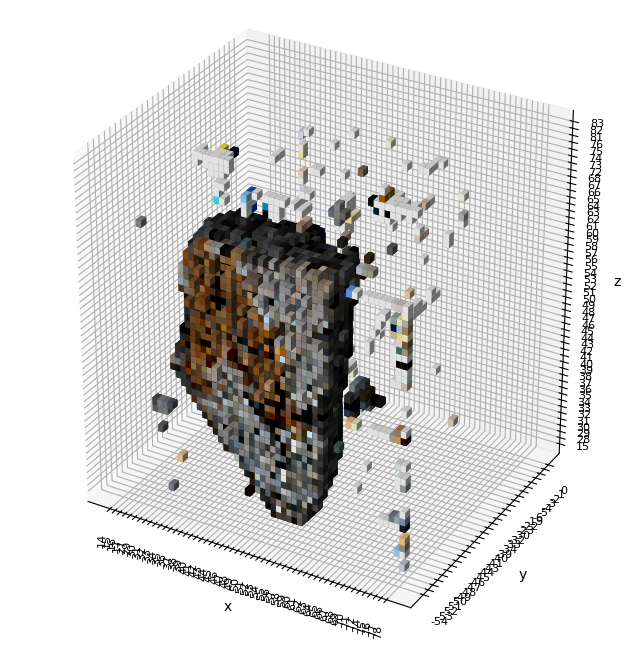

In [20]:
plot_colored_voxels(idx_tensors, colour_tensor)


In [60]:
def filter_by_cord(in_idx_tensors, in_colour_tensor, limits):
    out_idx_tensors = in_idx_tensors
    out_colour_tensor = in_colour_tensor
    for ax, (min, max) in enumerate(limits):

        new_filter = torch.logical_and(out_idx_tensors[ax] > min, out_idx_tensors[ax] < max)
        out_idx_tensors = [x[new_filter] for x in out_idx_tensors]
        out_colour_tensor = out_colour_tensor[new_filter]
    return out_idx_tensors, out_colour_tensor

In [61]:
idx_tensors[0]

tensor([14, 14, 15,  ..., 78, 78, 78], dtype=torch.int32)

/home/enego/Documents/masters/RayRepresentationTesting/NerfRepresentationUtils.py:112: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


(<Figure size 800x800 with 1 Axes>,
 <Axes3D: xlabel='x', ylabel='y', zlabel='z'>)

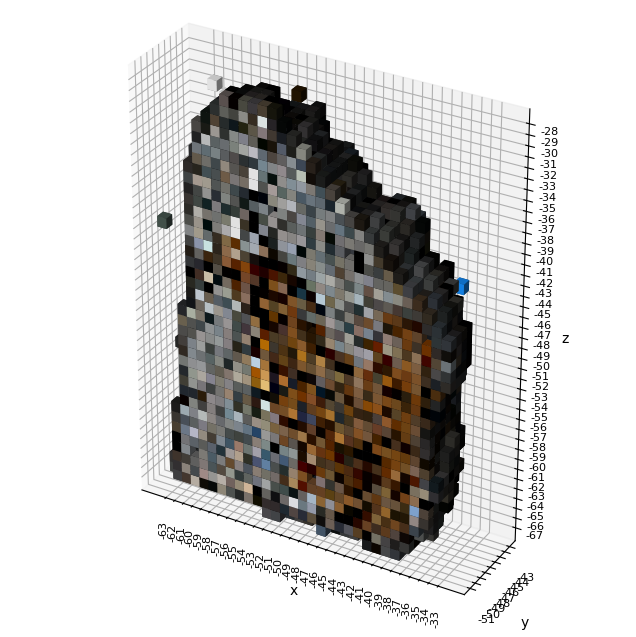

In [71]:
plot_colored_voxels(*filter_by_cord(idx_tensors, colour_tensor, [(32, 64), (40, 52), (26, 69)]), axis_flips=(-1, -1, -1))